# Carbon Paradox

## Worth its weight in carbon?

### An Analysis of Net-Positive Machine Learning in Grid Carbon Forecasting

## Setup

In [53]:
import pandas as pd
import os
import sys
from pathlib import Path

ROOT = Path(r"C:\Users\erinb\OneDrive\Documents\Georgetown\DSAN 5550\carbon-paradox")
os.chdir(ROOT)
sys.path.append(str(ROOT))

DATA_DIR = ROOT / "data" / "processed"
OUT_DIR = ROOT / "out"

from src.visualization import plot_codecarbon, plot_model_comparison, plot_predictions

## Processed Data

In [54]:
generation = pd.read_csv(DATA_DIR / "generation_by_fuel_hourly.csv")
emissions = pd.read_csv(DATA_DIR / "emissions_factors_by_fuel.csv")
regions = pd.read_csv(DATA_DIR / "egrid_region_reference.csv")
subregions = pd.read_csv(DATA_DIR / "egrid_subregions.csv")
edges = pd.read_csv(DATA_DIR / "grid_edges.csv")

In [55]:
generation.head()

,timestamp,region,region_name,fuel_type,generation_mwh
0,2024-01-01T00,CISO,California Independent System Operator,Coal,0
1,2024-01-01T00,CISO,California Independent System Operator,Natural Gas,10409
2,2024-01-01T00,CISO,California Independent System Operator,Nuclear,2232
3,2024-01-01T00,CISO,California Independent System Operator,Petroleum,46
4,2024-01-01T00,CISO,California Independent System Operator,Other,-131


In [56]:
emissions

,fuel_type,kgco2e_per_mwh
0,Coal,1000.0
1,Natural Gas,450.0
2,Petroleum,780.0
3,Other Gases,600.0
4,Nuclear,12.0
5,Hydro,24.0
6,Wind,11.0
7,Solar,45.0
8,Biomass,230.0
9,Geothermal,38.0


In [57]:
regions.head()

,region_code,region_name,annual_co2_rate
0,SUBRGN,SRNAME,SRCO2AN
1,AKGD,ASCC Alaska Grid,2292658.457
2,AKMS,ASCC Miscellaneous,411710.53
3,AZNM,WECC Southwest,61769179.175
4,CAMX,WECC California,47342486.547


In [58]:
subregions.head()

,region_code,region_name
0,AKGD,AKGD
1,AKMS,AKMS
2,AZNM,AZNM
3,CAMX,CAMX
4,ERCT,ERCT


In [59]:
edges.head()

,source_region,target_region,edge_type
0,AKGD,AKMS,adjacent_subregion
1,AZNM,CAMX,adjacent_subregion
2,AZNM,ERCT,adjacent_subregion
3,AZNM,MROW,adjacent_subregion
4,AZNM,NWPP,adjacent_subregion


## Preprocessed Model Data

In [60]:
model_data = pd.read_csv(DATA_DIR / "model_ready_data.csv")
model_data.head()

,timestamp,region,region_name,total_generation_mwh,total_co2_kg,carbon_intensity_kg_per_mwh,hour,day_of_week,month,lag_1,lag_24,target_carbon_intensity_24h
0,2024-01-02 00:00:00,CISO,California Independent System Operator,19732,4149260.0,210.280762,0,1,1,236.791290,266.008324,228.984253
1,2024-01-02 01:00:00,CISO,California Independent System Operator,18429,3881927.0,210.642303,1,1,1,210.280762,284.906921,236.813868
2,2024-01-02 02:00:00,CISO,California Independent System Operator,17709,4766326.0,269.147100,2,1,1,210.642303,294.015846,272.561522
3,2024-01-02 03:00:00,CISO,California Independent System Operator,19440,5384713.0,276.991409,3,1,1,269.147100,276.442321,259.718885
4,2024-01-02 04:00:00,CISO,California Independent System Operator,19920,5552338.0,278.731827,4,1,1,276.991409,284.719560,261.548556



These tables show the main inputs to the project: hourly generation by fuel from EIA, a fuel-level emissions lookup, and eGRID-based geographic reference data. The generation data provides the time-varying signal for forecasting, while the emissions factors are used to convert generation mix into estimated carbon intensity. The final, preprocessed table is the model-ready dataset built from the raw inputs. Each row represents one region-hour observation, with engineered time features and lag features added to support day-ahead forecasting.

## Baseline Model

In [61]:
baseline_metrics = pd.read_csv(OUT_DIR / "baseline_metrics.csv")
baseline_predictions = pd.read_csv(OUT_DIR / "baseline_predictions.csv")
baseline_codecarbon = pd.read_csv(OUT_DIR / "baseline_codecarbon.csv")

In [62]:
baseline_metrics

,metric,value
0,mae,48.997439
1,rmse,80.686959


In [63]:
baseline_predictions.head()

,timestamp,region,region_name,total_generation_mwh,total_co2_kg,carbon_intensity_kg_per_mwh,hour,day_of_week,month,lag_1,lag_24,target_carbon_intensity_24h,actual,prediction
0,2024-01-06 00:00:00,CISO,California Independent System Operator,21359,4588227.0,214.814692,0,5,1,235.065509,201.555270,183.162556,183.162556,213.68492
1,2024-01-06 00:00:00,PJM,"PJM Interconnection, LLC",108956,42052608.0,385.959543,0,5,1,388.546032,387.248834,390.507438,390.507438,396.21408
2,2024-01-06 00:00:00,SWPP,Southwest Power Pool,33047,18986983.0,574.544830,0,5,1,569.348763,444.867342,469.742308,469.742308,450.34387
3,2024-01-06 00:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",48012,18498191.0,385.282659,0,5,1,258.484078,423.830329,415.184018,415.184018,362.75623
4,2024-01-06 00:00:00,MISO,"Midcontinent Independent System Operator, Inc.",82634,45418719.0,549.637183,0,5,1,551.147762,556.754217,558.655643,558.655643,566.19360


In [64]:
baseline_codecarbon

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,latitude,ram_total_size,tracking_mode,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,on_cloud,pue,wue
0,2026-04-01T16:41:51,carbon_paradox_baseline,3b0806e1-d9a4-4e5c-a8a9-33a2800a32d7,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,1.623680,0.000001,7.584788e-07,8.093020,0.0,10.0,...,38.8957,15.406086,machine,0,0,0,0,N,1.0,0.0
1,2026-04-01T17:13:06,carbon_paradox_baseline,fad24a75-2c72-494c-b413-1ce109e98345,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,1.640564,0.000001,7.333663e-07,7.415647,0.0,10.0,...,38.8957,15.406086,machine,0,0,0,0,N,1.0,0.0
2,2026-04-14T17:13:23,carbon_paradox_baseline,912e4f06-4f0f-40b7-ab01-64a5f7173491,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,1.655731,0.000002,1.176899e-06,6.618702,0.0,10.0,...,38.8476,15.406086,machine,0,0,0,0,N,1.0,0.0
3,2026-04-14T17:17:05,carbon_paradox_baseline,e79173de-1990-4c3e-8d63-144bb449c5a4,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,1.599963,0.000002,1.218606e-06,7.332348,0.0,10.0,...,38.8476,15.406086,machine,0,0,0,0,N,1.0,0.0


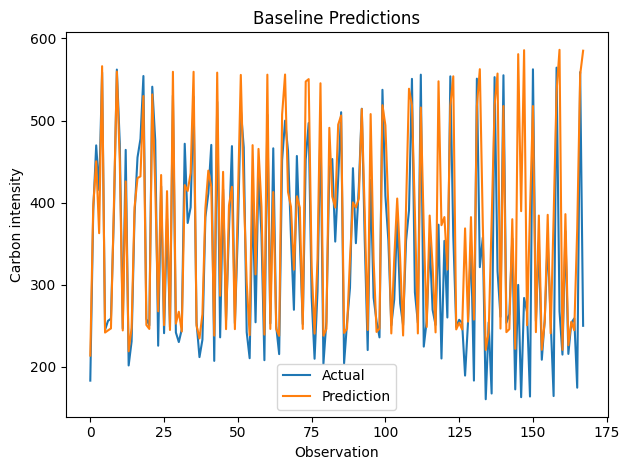

In [65]:
plot_predictions(OUT_DIR / "baseline_predictions.csv", "Baseline Predictions", OUT_DIR / "baseline_predictions.png")

The baseline outputs show that the XGBoost model is able to produce stable day-ahead predictions on the correct scale of carbon intensity values. The prediction plot suggests that the model follows the overall variation in the series reasonably well, though it still misses some sharper changes, and the CodeCarbon results show that it can be trained at a very low computational cost.

## GNN Model

In [66]:
gnn_metrics = pd.read_csv(OUT_DIR / "gnn_metrics.csv")
gnn_predictions = pd.read_csv(OUT_DIR / "gnn_predictions.csv")
gnn_codecarbon = pd.read_csv(OUT_DIR / "gnn_codecarbon.csv")

In [67]:
gnn_metrics

,metric,value
0,mae,87.643898
1,rmse,110.634088


In [68]:
gnn_predictions.head()

,timestamp,region,actual,prediction
0,2024-01-06 00:00:00,CISO,183.16255,166.27007
1,2024-01-06 00:00:00,ERCO,415.18402,572.42114
2,2024-01-06 00:00:00,ISNE,255.94745,195.75873
3,2024-01-06 00:00:00,MISO,558.65564,638.06274
4,2024-01-06 00:00:00,NYIS,244.92620,290.82434


In [69]:
gnn_codecarbon

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,latitude,ram_total_size,tracking_mode,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,on_cloud,pue,wue
0,2026-04-01T16:48:36,carbon_paradox_gnn,e6c5dd72-734a-4939-86b4-efe163532733,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,59.274861,0.000058,9.760556e-07,6.641303,0.0,10.0,...,38.8957,15.406086,machine,1.252632,0,80.626316,12.421269,N,1.0,0.0
1,2026-04-01T17:03:26,carbon_paradox_gnn,590cc0f1-c576-4517-86b7-aaee8d7a6c00,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,61.595581,0.000069,1.124824e-06,5.390250,0.0,10.0,...,38.8957,15.406086,machine,0.000000,0,84.425424,13.006537,N,1.0,0.0
2,2026-04-01T17:11:54,carbon_paradox_gnn,e904c870-092b-477d-aa80-a966e942e620,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,50.615378,0.000049,9.668787e-07,6.499277,0.0,10.0,...,38.8957,15.406086,machine,0.000000,0,80.689583,12.430617,N,1.0,0.0
3,2026-04-01T17:32:49,carbon_paradox_gnn,683088a6-7e9d-4d41-9db4-927bd9191402,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,52.780583,0.000052,9.906135e-07,6.957521,0.0,10.0,...,38.8957,15.406086,machine,0.000000,0,82.242000,12.669152,N,1.0,0.0
4,2026-04-01T17:35:21,carbon_paradox_gnn,32303a94-7b66-4923-9bdd-eeeab7a8e702,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,47.665535,0.000047,9.784321e-07,6.560730,0.0,10.0,...,38.8957,15.406086,machine,2.222222,0,83.053333,12.794554,N,1.0,0.0
5,2026-04-14T17:15:14,carbon_paradox_gnn,8cb570eb-f8ea-4ff8-a810-54f62861a1d7,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,87.638084,0.000141,1.609871e-06,6.261616,0.0,10.0,...,38.8476,15.406086,machine,0.000000,0,82.423529,12.699088,N,1.0,0.0
6,2026-04-14T17:19:39,carbon_paradox_gnn,479bb34b-587e-463a-81e5-a431b5060c7f,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,131.719838,0.000211,1.604118e-06,6.199781,0.0,10.0,...,38.8476,15.406086,machine,0.260156,0,84.792187,13.063269,N,1.0,0.0


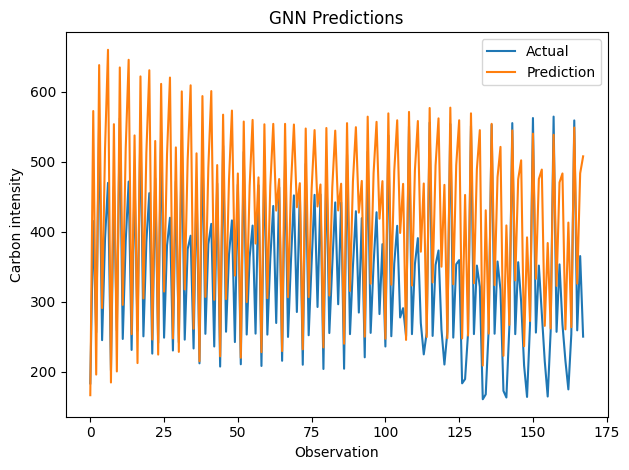

In [70]:
plot_predictions(OUT_DIR / "gnn_predictions.csv", "GNN Predictions", OUT_DIR / "gnn_predictions.png")

The GNN outputs show that the graph-based model is also learning the general range and movement of carbon intensity rather than producing unstable or unrealistic values. The prediction plot indicates that the model captures broad trends but tends to smooth out more abrupt swings, while the CodeCarbon table shows that incorporating graph structure comes with a noticeably higher computational footprint.

## Evaluation

In [71]:
comparison = pd.read_csv(OUT_DIR / "model_comparison.csv")
simulation = pd.read_csv(OUT_DIR / "charging_simulation.csv")
break_even = pd.read_csv(OUT_DIR / "break_even_analysis.csv")

In [72]:
comparison

,metric,value_baseline,value_gnn
0,mae,48.997439,87.643898
1,rmse,80.686959,110.634088


In [73]:
simulation.head()

,model,region,date,random_timestamp,optimized_timestamp,random_actual_carbon_intensity,optimized_actual_carbon_intensity,emissions_saved_kg
0,baseline,CISO,2024-01-06,2024-01-06 08:00:00,2024-01-06 00:00:00,254.240452,183.162556,0.710779
1,baseline,ERCO,2024-01-06,2024-01-06 08:00:00,2024-01-06 00:00:00,466.160174,415.184018,0.509762
2,baseline,ISNE,2024-01-06,2024-01-06 08:00:00,2024-01-06 05:00:00,208.056179,211.806794,-0.037506
3,baseline,MISO,2024-01-06,2024-01-06 08:00:00,2024-01-06 12:00:00,506.974979,510.131446,-0.031565
4,baseline,NYIS,2024-01-06,2024-01-06 08:00:00,2024-01-06 14:00:00,252.860665,250.544809,0.023159


In [74]:
break_even

,model,training_emissions_kg,average_savings_per_session_kg,sessions_to_break_even
0,baseline,0.000006,0.147711,0.000043
1,gnn,0.000627,0.643427,0.000975


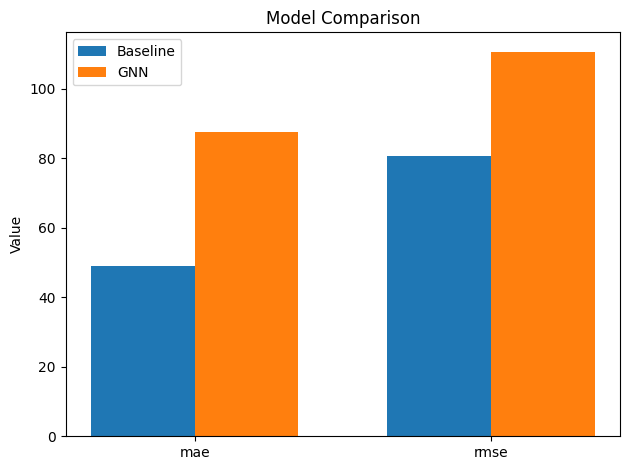

In [75]:
plot_model_comparison(OUT_DIR / "model_comparison.png")

In [76]:
codecarbon_summary = pd.DataFrame({
    "model": ["baseline", "gnn"],
    "duration_seconds": [
        baseline_codecarbon["duration"].iloc[0],
        gnn_codecarbon["duration"].iloc[0],
    ],
    "energy_consumed_kwh": [
        baseline_codecarbon["energy_consumed"].iloc[0],
        gnn_codecarbon["energy_consumed"].iloc[0],
    ],
    "emissions_kg_co2eq": [
        baseline_codecarbon["emissions"].iloc[0],
        gnn_codecarbon["emissions"].iloc[0],
    ],
    "cpu_model": [
        baseline_codecarbon["cpu_model"].iloc[0],
        gnn_codecarbon["cpu_model"].iloc[0],
    ],
    "region": [
        baseline_codecarbon["region"].iloc[0],
        gnn_codecarbon["region"].iloc[0],
    ],
})

codecarbon_summary

,model,duration_seconds,energy_consumed_kwh,emissions_kg_co2eq,cpu_model,region
0,baseline,1.623680,0.000006,0.000001,AMD Ryzen 7 5800H with Radeon Graphics,district of columbia
1,gnn,59.274861,0.000265,0.000058,AMD Ryzen 7 5800H with Radeon Graphics,district of columbia


In [77]:
tradeoff = comparison.copy()
tradeoff["model"] = tradeoff["metric"]
tradeoff = tradeoff.drop(columns=["metric"])

tradeoff = pd.DataFrame({
    "model": ["baseline", "gnn"],
    "mae": [
        comparison.loc[comparison["metric"] == "mae", "value_baseline"].iloc[0],
        comparison.loc[comparison["metric"] == "mae", "value_gnn"].iloc[0],
    ],
    "rmse": [
        comparison.loc[comparison["metric"] == "rmse", "value_baseline"].iloc[0],
        comparison.loc[comparison["metric"] == "rmse", "value_gnn"].iloc[0],
    ],
    "emissions_kg_co2eq": [
        codecarbon_summary.loc[codecarbon_summary["model"] == "baseline", "emissions_kg_co2eq"].iloc[0],
        codecarbon_summary.loc[codecarbon_summary["model"] == "gnn", "emissions_kg_co2eq"].iloc[0],
    ],
    "energy_consumed_kwh": [
        codecarbon_summary.loc[codecarbon_summary["model"] == "baseline", "energy_consumed_kwh"].iloc[0],
        codecarbon_summary.loc[codecarbon_summary["model"] == "gnn", "energy_consumed_kwh"].iloc[0],
    ],
    "sessions_to_break_even": [
        break_even.loc[break_even["model"] == "baseline", "sessions_to_break_even"].iloc[0],
        break_even.loc[break_even["model"] == "gnn", "sessions_to_break_even"].iloc[0],
    ],
})

tradeoff


,model,mae,rmse,emissions_kg_co2eq,energy_consumed_kwh,sessions_to_break_even
0,baseline,48.997439,80.686959,0.000001,0.000006,0.000043
1,gnn,87.643898,110.634088,0.000058,0.000265,0.000975


The evaluation results show that the baseline is the stronger forecasting model on this dataset, with lower error across both metrics. In the charging simulation, the baseline achieved average savings of about 0.1477 kg CO2 per 10 kWh session, while the GNN achieved average savings of about 0.6434 kg, though those values come from a simplified simulation over a limited evaluation window. The break-even analysis suggests that the baseline would offset its training emissions after about 0.0000429 sessions and the GNN after about 0.000975 sessions, which indicates that training emissions are very small relative to the simulated operational savings. Scaled up for intuition, if each model were trained one million times, the baseline would need about 43 optimized charging sessions to offset its carbon cost, while the GNN would need about 975 sessions.


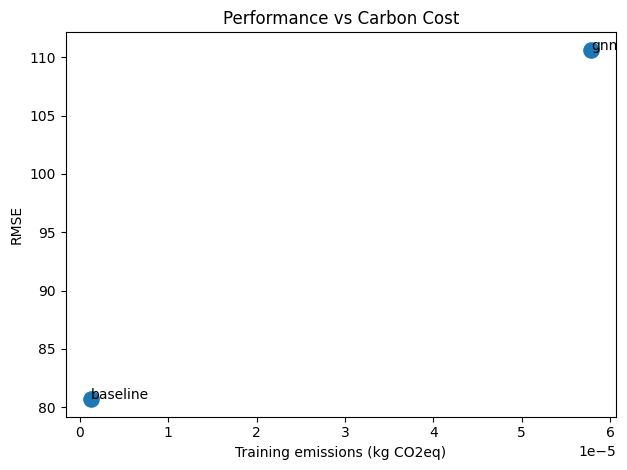

In [78]:
import matplotlib.pyplot as plt

plt.scatter(tradeoff["emissions_kg_co2eq"], tradeoff["rmse"], s=120)

for _, row in tradeoff.iterrows():
    plt.text(row["emissions_kg_co2eq"], row["rmse"], row["model"])

plt.xlabel("Training emissions (kg CO2eq)")
plt.ylabel("RMSE")
plt.title("Performance vs Carbon Cost")
plt.tight_layout()
plt.savefig(OUT_DIR / "performance_vs_carbon_cost.png", dpi=300, bbox_inches="tight")
plt.show()


The tradeoff view combines forecasting error with training emissions in a single summary. The baseline sits at RMSE = 80.687 with 6.33e-06 kg CO2eq, while the GNN sits at RMSE = 110.634 with 6.27e-04 kg CO2eq. In the current setup, this means the baseline delivers both better predictive performance and lower computational cost. The baseline not only predicted more accurately, with an RMSE of 80.7 versus 110.6 for the GNN, but did so at a much lower carbon cost: roughly 6 milligrams of CO2-equivalent for training compared with roughly 627 milligrams for the GNN.